# 单个 off-bin CW：MeerKAT regularised clean / radiometer power

人工 ideal PTA → DEFIANT narrowband PFOS → cartography modified MAPS → 官方 MATLAB `makemap` / `diagPixel`。
逐 cell 执行，检查输出后再决定正则化。这里的有限窗泄漏是研究对象；**不将 clean 或 radiometer power 当作 CW 检测统计量**。

固定 benchmark：25 pulsars，RA = 6 h，Dec = −45°，$f_\mathrm{CW}=2.5/T$；仅 Earth term、无演化、无随机噪声/GWB 注入。
保留 canonical baseline 的 TOA errors（每点 0.1 μs）以及原有 Offset timing column。

上游：[cartography @ 67beabce](https://github.com/mpta-gw/cartography/tree/67beabce445b3391bce488c8162581542d6608b6)。
接口差异、坐标与单位见 `external/COMPATIBILITY.md`。clean 与 radiometer 都使用上游像素转换；不使用自写 sky reconstruction。


## 00. Imports and fixed configuration

In [1]:
from pathlib import Path
from copy import deepcopy, copy
import hashlib, importlib.metadata, json, logging, os, shutil, subprocess, sys
import numpy as np
import pandas as pd
import scipy.linalg as sla
from scipy.io import savemat, loadmat
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display
import astropy.units as u
from pint.logging import setup as setup_pint_logging
from pint.residuals import Residuals
from pta_replicator.deterministic import add_cgw
from enterprise.pulsar import Pulsar
from enterprise.signals import gp_signals, parameter, signal_base, utils, white_signals
from defiant import OptimalStatistic

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "environment.yml").exists())
sys.path.insert(0, str(ROOT / "src"))
from leakage.datasets import load_pulsar, sha256, verify_dataset
from leakage.injection_validation import diagnose_cw_injection
from leakage.cartography_runtime import load_cartography
setup_pint_logging(level="ERROR")
logging.getLogger("enterprise.pulsar").setLevel(logging.ERROR)

N_PSR = 25
SOURCE_RA = np.pi / 2
SOURCE_DEC = -np.pi / 4
CW_CYCLES = 2.5
BASELINE = ROOT / "data/baseline/ideal_25psr"
INJECTION = ROOT / "data/injections/cw/ra6h_dec-45_f2p5T"
PRODUCTS = ROOT / "data/products/meerkat_maps/cw_ra6h_dec-45_f2p5T"
PRODUCTS.mkdir(parents=True, exist_ok=True)
BINS = (1, 2, 3, 4)
# Spatial integration grid follows the upstream example; lmax is decided below.
NSIDE = 16
N_FOURIER = 10  # same number of Fourier components as the official example
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
                     "axes.linewidth": 0.7, "savefig.dpi": 400,
                     "pdf.fonttype": 42, "ps.fonttype": 42})

def write_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, ensure_ascii=False) + "\n")

maps_module, provenance = load_cartography(ROOT)
print(provenance)
print("DEFIANT:", importlib.metadata.version("defiant"))
for distribution, expected in [("defiant", "25d38082bbf2b9b33829f59438ac66a5dfc112fa"), ("pta-replicator", "a2147f7b268b8111290b3c98a9cd416a6e8eaf69")]:
    direct = json.loads(importlib.metadata.distribution(distribution).read_text("direct_url.json") or "{}")
    assert direct.get("vcs_info", {}).get("commit_id") == expected, f"Wrong {distribution} commit: install the lock file"


libstempo not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


{'commit': '67beabce445b3391bce488c8162581542d6608b6', 'compatibility_patch_sha256': '7429a1b7f874460526c9264c842efb34fd9f7dcdd8c41bf9bad26fc9623bb404', 'basis_coordinates': 'propagation; apply explicit antipodal coordinate conversion after makemap'}
DEFIANT: 0.4.4


## 01. Load the canonical 25-pulsar ideal PTA
`metadata.json` 验证全部 50 个输入文件；不重新 `make_ideal`，不重采样，不生成新的 pulsar sky。
PINT loader 显式传入 par model，以保留 `TT(BIPM2016)` 与 `DE440`。

In [2]:
baseline_metadata = verify_dataset(BASELINE, "metadata.json")
names = [f"J{i:02d}" for i in range(N_PSR)]
ideal_psrs = [load_pulsar(BASELINE / "par" / f"{n}.par", BASELINE / "tim" / f"{n}.tim") for n in names]
nominal_mjd = np.array(baseline_metadata["config"]["obstimes_mjd"])
baseline_enterprise = [Pulsar(p.toas, p.model, timing_package="pint", planets=False) for p in ideal_psrs]
T_OBS = float(max(p.toas.max() for p in baseline_enterprise) - min(p.toas.min() for p in baseline_enterprise))
DF = 1 / T_OBS
F_CW = CW_CYCLES * DF
TREF = float(nominal_mjd[0] * 86400)
print("Canonical sampling:", len(ideal_psrs), "pulsars;", len(nominal_mjd), "epochs")
print("Timing columns:", ideal_psrs[0].model.designmatrix(ideal_psrs[0].toas)[1])

Canonical sampling: 25 pulsars; 261 epochs
Timing columns: ['Offset']


## 02. Load / construct the single-CW injected dataset
质量、距离和取向沿用手写记录：$\mathcal M=10^9M_\odot$、$D=100$ Mpc、phase = 0、inclination = π/3、polarisation = 0。
只有 sky position 与频率改为本 benchmark。首次执行才写新 dataset；已有数据必须通过 metadata 和 SHA256 检查。
注入前后模型相同，不做 timing refit。

In [3]:
cw_parameters = dict(ra_deg=90.0, dec_deg=-45.0, fCW_hz=F_CW, fCW_T=CW_CYCLES,
    chirp_mass_solar=1e9, distance_mpc=100.0, phase_rad=0.0,
    inclination_rad=float(np.pi / 3), polarisation_rad=0.0,
    psrTerm=False, evolve=False, phase_approx=False, tref_seconds=TREF)
parent_hash = sha256(BASELINE / "metadata.json")
if not INJECTION.exists():
    injected = deepcopy(ideal_psrs)
    for p in injected:
        add_cgw(p, gwtheta=np.pi/2-SOURCE_DEC, gwphi=SOURCE_RA,
                mc=cw_parameters["chirp_mass_solar"], dist=cw_parameters["distance_mpc"],
                fgw=F_CW, phase0=0.0, psi=0.0, inc=np.pi/3,
                psrTerm=False, evolve=False, phase_approx=False,
                tref=TREF, signal_name="cw")
    diagnostics = [diagnose_cw_injection(a, b) for a, b in zip(ideal_psrs, injected)]
    assert max(d["raw"]["max_abs_ns"] for d in diagnostics) < 3
    # Prepare completely before the atomic dataset rename.
    staging = ROOT / "data/cache/single_cw_staging"
    if staging.exists(): shutil.rmtree(staging)
    for suffix in ("par", "tim"): (staging / suffix).mkdir(parents=True, exist_ok=True)
    for p in injected:
        p.write_partim(staging / "par" / f"{p.name}.par", staging / "tim" / f"{p.name}.tim", tempo2=True)
    injection_metadata = {"schema_version": 1, "dataset_type": "single_cw",
        "parent_baseline": str(BASELINE.relative_to(ROOT)), "parent_metadata_sha256": parent_hash,
        "parameters": cw_parameters, "T_obs_seconds": T_OBS,
        "T_definition": "global barycentric span of canonical baseline in enterprise; held fixed for injection and Fourier basis",
        "no_random_noise_injected": True,
        "software": {n: importlib.metadata.version(n) for n in ("pint-pulsar", "pta-replicator", "numpy", "astropy")},
        "pta_replicator_commit": "a2147f7b268b8111290b3c98a9cd416a6e8eaf69",
        "in_memory_validation": [{k:v for k,v in d.items() if k in ("pulsar", "raw", "projected")} for d in diagnostics],
        "files": {str(p.relative_to(staging)): sha256(p) for suffix in ("par", "tim") for p in sorted((staging/suffix).glob("*"))}}
    write_json(staging / "injection.json", injection_metadata)
    verify_dataset(staging, "injection.json")
    INJECTION.parent.mkdir(parents=True, exist_ok=True)
    staging.rename(INJECTION)
injection_metadata = verify_dataset(INJECTION, "injection.json")
assert injection_metadata["parent_metadata_sha256"] == parent_hash
assert injection_metadata["parameters"] == cw_parameters
psrs = [load_pulsar(INJECTION / "par" / f"{n}.par", INJECTION / "tim" / f"{n}.tim") for n in names]
print(INJECTION.relative_to(ROOT), "verified,", len(psrs), "pulsars")

data/injections/cw/ra6h_dec-45_f2p5T verified, 25 pulsars


## 03. Verify basic PTA / CW metadata

In [4]:
enterprise_psrs = [Pulsar(p.toas, p.model, timing_package="pint", planets=False) for p in psrs]
actual_span = max(p.toas.max() for p in enterprise_psrs) - min(p.toas.min() for p in enterprise_psrs)
ra = np.array([p.phi for p in enterprise_psrs])
dec = np.pi/2 - np.array([p.theta for p in enterprise_psrs])
assert len(psrs) == N_PSR
assert all(len(p.toas) == 261 for p in enterprise_psrs)
assert all(np.allclose(p.toaerrs, 1e-7, rtol=0, atol=1e-20) for p in enterprise_psrs)
assert all(p.Mmat.shape[1] == 1 for p in enterprise_psrs), "Only the canonical Offset is allowed"
assert abs(actual_span / T_OBS - 1) < 1e-8
cadence_deviation_s = max(float(np.max(np.abs(np.diff(p.toas) - 14*86400))) for p in enterprise_psrs)
display(pd.DataFrame({"quantity": ["N pulsars", "T_obs [s]", "enterprise span [s]", "1/T [nHz]", "f_CW [nHz]", "f_CW T", "RA [h]", "Dec [deg]", "max cadence deviation [s]"],
    "value": [N_PSR, T_OBS, actual_span, DF*1e9, F_CW*1e9, F_CW*T_OBS, 6, -45, cadence_deviation_s]}))
# Round-trip check against a fresh injection from the canonical parent.
roundtrip = []
for baseline, loaded in zip(ideal_psrs, psrs):
    fresh = deepcopy(baseline)
    add_cgw(fresh, gwtheta=np.pi/2-SOURCE_DEC, gwphi=SOURCE_RA, mc=1e9, dist=100,
            fgw=F_CW, phase0=0, psi=0, inc=np.pi/3, psrTerm=False, evolve=False,
            phase_approx=False, tref=TREF, signal_name="cw")
    loaded.added_signals_time = fresh.added_signals_time
    roundtrip.append(diagnose_cw_injection(baseline, loaded))
assert max(d["raw"]["max_abs_ns"] for d in roundtrip) < 3
print("PINT raw round-trip worst error [ns]:", max(d["raw"]["max_abs_ns"] for d in roundtrip))
write_json(PRODUCTS / "input_validation.json", {"canonical_span_seconds":T_OBS,
    "enterprise_span_seconds":actual_span, "max_cadence_deviation_seconds":cadence_deviation_s,
    "roundtrip": [{k:v for k,v in d.items() if k in ("pulsar", "raw", "projected")} for d in roundtrip]})

,quantity,value
0,N pulsars,2.500000e+01
1,T_obs [s],3.144969e+08
2,enterprise span [s],3.144969e+08
3,1/T [nHz],3.179681e+00
4,f_CW [nHz],7.949203e+00
5,f_CW T,2.500000e+00
6,RA [h],6.000000e+00
7,Dec [deg],-4.500000e+01
8,max cadence deviation [s],1.208383e+02


PINT raw round-trip worst error [ns]: 0.7676549389737978


## 04. Construct the enterprise PTA model required by DEFIANT
沿用官方 WN-only 模型分支的 `TimingModel(use_svd=True)`、measurement EFAC、10 个 `gw` Fourier components。
canonical timing design 只有 Offset；这里不增加 F0/F1 等拟合列。
原始 AXIS 数据的 nominal MJD 是等间隔的；enterprise 使用 barycentric TOA，故继承微小 cadence 偏差，记录但不开展 irregular-sampling 研究。T 取 baseline 的实际 barycentric span，所有 bins 与注入统一使用此 T。

DEFIANT 要求 `gw` Fourier GP 的正谱。真实 stochastic power 是零，因此将 `gw_log10_A=-20, gamma=0` 明示为**数值正值底限**，不是 GWB 注入或拟合结果。
其谱在当前 white-noise Fourier variance 的 $10^{-10}$ 以下。所有 pulsars 的 EFAC = 1。
调用官方 full pair covariance；在这一 white-noise 极限它应接近对角阵。
它不代表这一个 coherent CW realization 的完整物理协方差，也不用于置信度或显著性推断。

In [5]:
timing = gp_signals.TimingModel(use_svd=True)
white = white_signals.MeasurementNoise(efac=parameter.Constant(1.0))
# Uniform merely exposes the named parameter expected by DEFIANT; no parameter sampling.
gw_spectrum = utils.powerlaw(log10_A=parameter.Uniform(-22, -18)("gw_log10_A"),
                            gamma=parameter.Constant(0.0)("gw_gamma"))
gw = gp_signals.FourierBasisGP(gw_spectrum, components=N_FOURIER, Tspan=T_OBS, name="gw")
model = timing + white + gw
pta = signal_base.PTA([model(p) for p in enterprise_psrs])
noisedict = {"gw_log10_A": -20.0, "gw_gamma": 0.0, **{f"{n}_efac":1.0 for n in names}}
pta.set_default_params(noisedict)
print(pta.summary())
write_json(PRODUCTS / "noise_model.json", noisedict)

enterprise v3.5.0,  Python v3.11.15

Signal Name                              Signal Class                   no. Parameters      
J00_linear_timing_model_svd              TimingModel                    0                   

params:
__________________________________________________________________________________________
J00_measurement_noise                    MeasurementNoise               0                   

params:
J00_efac:Constant=1.0                                                                     
__________________________________________________________________________________________
J00_gw                                   FourierBasisGP                 1                   

Basis shape (Ntoas x N basis functions): (261, 20)
N selected toas: 261

params:
gw_log10_A:Uniform(pmin=-22, pmax=-18)                                                    
gw_gamma:Constant=0.0                                                                     
____________________________________

## 05. Construct `OptimalStatistic(...)`

In [6]:
os_obj = OptimalStatistic(enterprise_psrs, pta, gwb_name="gw", sub_tqdm=False)
os_obj.set_orf(["hd"])
pair_idx = np.array(os_obj._pair_idx)
assert np.array_equal(pair_idx, np.array(np.triu_indices(N_PSR, 1)).T)
np.testing.assert_allclose(os_obj.freqs, np.arange(1, N_FOURIER+1) / T_OBS, rtol=1e-12)
phi_template = next(s for s in pta._signalcollections[0].signals if s.signal_id == "gw").get_phi(noisedict)  # diagnostic only: exact spectrum supplied to DEFIANT
white_fourier_variance = 2*(1e-7)**2/len(nominal_mjd)
print("Template / white Fourier variance:", np.max(phi_template)/white_fourier_variance)
assert np.max(phi_template)/white_fourier_variance < 1e-10
print("Pairs:", pair_idx.shape, "Fourier fT:", os_obj.freqs*T_OBS)

Template / white Fourier variance: 1.1010955302274917e-12
Pairs: (300, 2) Fourier fT: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


## 06. Run PFOS for physical Fourier bin k = 1
**DEFIANT `select_freq` 是零起始数组索引**：物理 bin $k$ 必须传 `k-1`。官方 driver 直接传 `args.fbin`，因而不能照搬其标签。
锁定的 2025-03-04 DEFIANT commit 返回官方 driver 所用的七元 tuple，未使用当前最新版。


In [7]:
k = BINS[0]
xi, rhok, sigk, covk, Sk, Sk_sigma, parameter_index = os_obj.compute_PFOS(params=noisedict, select_freq=k-1, narrowband=True,
    pair_covariance=True, return_pair_vals=True, use_tqdm=False)
Sk = float(Sk)
print("Physical bin:", k, "select_freq:", k-1, "fT:", os_obj.freqs[k-1]*T_OBS)

Physical bin: 1 select_freq: 0 fT: 1.0


## 07. Inspect all PFOS pair products

In [8]:
assert xi.shape == rhok.shape == sigk.shape == (300,)
assert covk.shape == (300, 300)
assert all(np.all(np.isfinite(a)) for a in (xi, rhok, sigk, covk, Sk))
assert np.all(sigk > 0) and Sk > 0  # upstream divides by Sk; fail explicitly if unsuitable
assert np.linalg.eigvalsh(covk).min() > 0
np.testing.assert_allclose(covk, covk.T, rtol=1e-12, atol=0)
display(pd.DataFrame({"pair": [f"{names[a]}–{names[b]}" for a,b in pair_idx[:8]],
    "xi [rad]": xi[:8], "rhok [s²]": rhok[:8], "sigk [s²]": sigk[:8]}))
for label, value in zip(("xi", "rhok", "sigk", "covk", "Sk"), (xi, rhok, sigk, covk, Sk)):
    print(label, np.shape(value), "range", np.min(value), np.max(value))
print("covk / max(abs(covk)), top-left block:", covk[:4,:4]/np.max(np.abs(covk)))
print("Off-diagonal covariance fraction:", np.linalg.norm(covk-np.diag(np.diag(covk)))/np.linalg.norm(covk))
out = PRODUCTS / "fbin_01"
out.mkdir(exist_ok=True)
np.savez_compressed(out / "pfos_pairs.npz", xi=xi, rhok=rhok, sigk=sigk, covk=covk,
                    Sk=Sk, pair_idx=pair_idx, frequency_hz=os_obj.freqs[0], physical_bin=k, select_freq=k-1)

,pair,xi [rad],rhok [s²],sigk [s²]
0,J00–J01,0.727656,7.649080e-20,5.418483e-17
1,J00–J02,0.671824,7.863221e-18,5.418483e-17
2,J00–J03,0.627620,-7.414675e-19,5.418483e-17
3,J00–J04,1.156502,-2.434845e-18,5.418483e-17
4,J00–J05,0.747585,1.001151e-18,5.418483e-17
5,J00–J06,1.162515,1.141254e-19,5.418483e-17
6,J00–J07,1.301846,6.265076e-18,5.418483e-17
7,J00–J08,0.980773,-4.999370e-18,5.418483e-17


xi (300,) range 0.6276199357461895 3.0281908697776476
rhok (300,) range -1.2216873327607887e-16 1.254368019139826e-16
sigk (300,) range 5.418482779708471e-17 5.418482780871744e-17
covk (300, 300) range -4.9105598029400645e-46 2.935995564660359e-33
Sk () range 5.935822740001158e-17 5.935822740001158e-17
covk / max(abs(covk)), top-left block: [[ 1.00000000e+00 -9.34601328e-14  8.10319694e-15  1.25264263e-13]
 [-9.34601328e-14  1.00000000e+00 -1.57664126e-13 -6.44599364e-14]
 [ 8.10319694e-15 -1.57664126e-13  1.00000000e+00 -1.65403204e-13]
 [ 1.25264263e-13 -6.44599364e-14 -1.65403204e-13  1.00000000e+00]]
Off-diagonal covariance fraction: 8.698453466865232e-13


## 08. Construct official modified `anis_pta`
先以 $l_{max}=8$ 作为**诊断上限**计算一次官方角响应（81 个复系数）。检查嵌套的 lmax = 2, 4, 6, 8 子空间，再决定本次展示的 lmax。
子空间只切片官方 `Gamma_lm`；不重新设计 response。复系数排序为 l-major, m = −l,…,+l。

兼容补丁将 `anis_pta` 连接到仓库自带的 `anis_coefficients.py`，因此这里保留该文件的 **propagation-direction** 基底。
最后在官方 `makemap` 输出坐标上做精确 antipodal 转换；绝不把 propagation hotspot 错标为 source position。
`os=Sk` 是上游归一化，必须保留并记录。

In [9]:
apta_diagnostic = maps_module.anis_pta(np.pi/2-dec, ra, xi, rhok, sigk,
    os_cov=covk, nside=NSIDE, l_max=8, os=Sk, mode="sph_basis", include_pta_monopole=False)

(81, 300)


## 09. Compute Fisher matrix M

In [10]:
M_diagnostic = apta_diagnostic.fisher_matrix_sph(cross_corr=True)

## 10. Hermiticity, rank, conditioning and nested basis spectra

In [11]:
assert np.linalg.norm(M_diagnostic-M_diagnostic.conj().T)/np.linalg.norm(M_diagnostic) < 1e-12
basis_rows, spectra = [], {}
for ell_max in (2, 4, 6, 8):
    candidate = copy(apta_diagnostic)
    candidate.Gamma_lm = apta_diagnostic.Gamma_lm[:(ell_max+1)**2]
    matrix = candidate.fisher_matrix_sph(cross_corr=True)
    singular = sla.svdvals(matrix)
    spectra[ell_max] = singular
    basis_rows.append({"lmax":ell_max, "N coefficients":len(singular),
                      "rank":np.linalg.matrix_rank(matrix), "condition":singular[0]/singular[-1],
                      "modes > 1% max":int(np.sum(singular > singular[0]*0.01))})
display(pd.DataFrame(basis_rows))
np.savez_compressed(PRODUCTS / "basis_diagnostics.npz", M_lmax8=M_diagnostic,
                    **{f"singular_lmax{l}":s for l,s in spectra.items()})

,lmax,N coefficients,rank,condition,modes > 1% max
0,2,9,9,8.442957,9
1,4,25,25,11.923993,25
2,6,49,49,100.669935,48
3,8,81,81,1553.924283,58


## 11. Diagnostic eigenspectrum (inspect before choosing a cutoff)

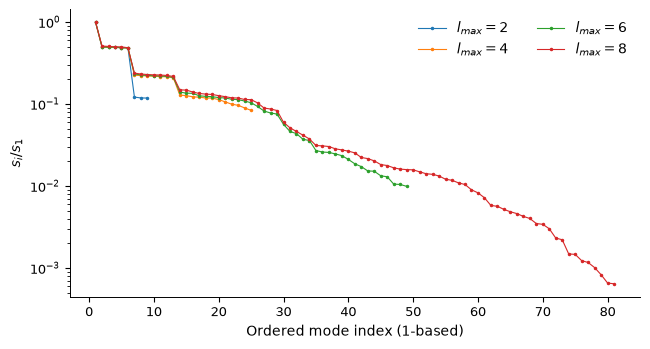

lmax 6 relative eigenvalues: [1.         0.49913882 0.49496475 0.49459147 0.48827154 0.48484387
 0.23325705 0.22694931 0.22334518 0.22161197 0.22044087 0.21754632
 0.21227922 0.14016996 0.13593815 0.13531528 0.12629435 0.12423442
 0.12319549 0.11995453 0.11874685 0.11452845 0.11336694 0.10894302
 0.10386746 0.09360769 0.08227183 0.07789349 0.07557678 0.05664036
 0.04634546 0.04365223 0.03722686 0.03592757 0.02714975 0.02603631
 0.02571847 0.02470272 0.02351262 0.02116662 0.01869089 0.01728439
 0.015315   0.01517891 0.01334934 0.01299729 0.01057965 0.01046999
 0.00993345]


In [12]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
for ell_max, singular in spectra.items():
    ax.semilogy(np.arange(1,len(singular)+1), singular/singular[0], ".-", ms=3, lw=0.8, label=fr"$l_{{max}}={ell_max}$")
ax.set(xlabel="Ordered mode index (1-based)", ylabel=r"$s_i/s_1$")
ax.legend(frameon=False, ncol=2)
ax.spines[["right", "top"]].set_visible(False)
fig.tight_layout()
fig.savefig(PRODUCTS / "fisher_basis_spectrum.png")
fig.savefig(PRODUCTS / "fisher_basis_spectrum.pdf")
plt.show()
print("lmax 6 relative eigenvalues:", spectra[6]/spectra[6][0])

## 12. Explicit regularisation decision
实测 lmax = 2,4,6,8 的 rank = 9,25,49,81；condition ≈ 8.44, 11.92, 100.67, 1553.92。
不存在唯一尖锐的谱断点，不能声称数据唯一决定了 cutoff。

本次选 **lmax = 6**：保留高于 l=4 的角结构，同时避开 l=8 新增的低响应尾部。
选择 **保留 29/49 个模**，使保留子空间 condition ≈ 13.23（工作上限设为 15）。
第 29、30 个模相对最大奇异值约 0.07558、0.05664；阈值 $1/15$ 在两者之间。
这是明确的 bias/variance 工作选择，不是通过峰值位置或显著性优化得到的值；并非宣称最优或最终科学分辨率。

上游普通分支把 `sv[cutoff]` 传给旧 SciPy 的 `cond`，有版本与相对/绝对阈值语义问题。
这里直接使用 **同一官方函数内已有的 `U_0/Vh_0` 分支**：`cutoff` 表示保留的矩阵子块大小（29），不做 driver 的 `cutoff-1`。
传入当前 M 的 SVD 基底，得到该子空间上的官方逆矩阵。

In [13]:
LMAX = 6
N_KEEP = 29
MAX_RETAINED_CONDITION = 15.0
apta = copy(apta_diagnostic)
apta.l_max, apta.clm_size = LMAX, (LMAX+1)**2
apta.Gamma_lm = apta_diagnostic.Gamma_lm[:apta.clm_size].copy()
M = apta.fisher_matrix_sph(cross_corr=True)
eigenvalues = sla.eigvalsh(M)
U0, singular_values, Vh0 = sla.svd(M)
assert np.all(eigenvalues > 0)
assert np.linalg.matrix_rank(M) == (LMAX+1)**2
assert singular_values[N_KEEP-1]/singular_values[0] > 1/MAX_RETAINED_CONDITION
assert singular_values[N_KEEP]/singular_values[0] < 1/MAX_RETAINED_CONDITION
print("M shape / Hermiticity / rank:", M.shape,
      np.linalg.norm(M-M.conj().T)/np.linalg.norm(M), np.linalg.matrix_rank(M))
print("M top-left:", M[:3,:3])
print("Eigenvalues ascending:", eigenvalues)
print("Full / retained condition:", singular_values[0]/singular_values[-1], singular_values[0]/singular_values[N_KEEP-1])
# Add the actual decision to the single diagnostic figure rather than making debug figures.
ax.axvline(N_KEEP+0.5, color="0.35", lw=0.8, ls="--")
ax.axhline(1/MAX_RETAINED_CONDITION, color="0.5", lw=0.6, ls=":")
fig.savefig(PRODUCTS / "fisher_basis_spectrum.png")
fig.savefig(PRODUCTS / "fisher_basis_spectrum.pdf")
np.save(PRODUCTS / "Gamma_lm.npy", apta.Gamma_lm)
write_json(PRODUCTS / "regularisation.json", dict(lmax=LMAX, retained_modes=N_KEEP,
    rule="retain the leading subspace with condition <= 15; explicit exploratory choice, not unique or significance-optimised",
    full_rank=int(np.linalg.matrix_rank(M)), full_condition=float(singular_values[0]/singular_values[-1]),
    retained_condition=float(singular_values[0]/singular_values[N_KEEP-1]),
    relative_last_retained=float(singular_values[N_KEEP-1]/singular_values[0]),
    relative_first_discarded=float(singular_values[N_KEEP]/singular_values[0]),
    branch="official max_lkl_clm(U_0=U, Vh_0=Vh, cutoff=N_KEEP)"))

M shape / Hermiticity / rank: (49, 49) 2.52614191157547e-16 49
M top-left: [[ 3.88670477e-01+0.00000000e+00j -1.02696885e-03-5.80431341e-04j
  -1.55961254e-05+0.00000000e+00j]
 [-1.02696885e-03+5.80431341e-04j  4.61687551e-02-1.35525272e-19j
   5.68646128e-06+1.93383907e-05j]
 [-1.55961254e-05+0.00000000e+00j  5.68646128e-06-1.93383907e-05j
   4.73341025e-02+0.00000000e+00j]]
Eigenvalues ascending: [0.00386329 0.00407196 0.00411461 0.00505487 0.00519179 0.00590334
 0.00595627 0.0067222  0.00726921 0.00823207 0.00914447 0.00960732
 0.01000236 0.01012597 0.01055901 0.01397286 0.01447817 0.01697711
 0.01802456 0.02202842 0.02939312 0.03029413 0.03199694 0.03640566
 0.04039586 0.04236983 0.04409037 0.04454211 0.04618271 0.0466524
 0.04791287 0.04831693 0.04911807 0.05262646 0.05286871 0.05451453
 0.08255908 0.08460755 0.08573329 0.08618875 0.08686283 0.08826453
 0.09071772 0.18856421 0.18989729 0.19235522 0.1925004  0.19412376
 0.38891739]
Full / retained condition: 100.66993467400323 13.2

## 13. Official `max_lkl_clm`: coefficients, inverse, X, covariance, singular values

In [14]:
clms, clm_err, condition, sv, Mprime_inv, X, U_svd, Vh_svd = apta.max_lkl_clm(
    use_svd_reg=True, cross_corr=True, cutoff=N_KEEP, U_0=U0, Vh_0=Vh0)
covariance = Mprime_inv @ M @ Mprime_inv  # exact expression in official driver
assert np.linalg.matrix_rank(Mprime_inv) == N_KEEP
np.testing.assert_allclose(clms, Mprime_inv @ X, rtol=1e-12, atol=1e-12)
assert np.linalg.norm(Mprime_inv-Mprime_inv.conj().T)/np.linalg.norm(Mprime_inv) < 1e-12
assert np.linalg.norm(covariance-covariance.conj().T)/np.linalg.norm(covariance) < 1e-12
lm = [(l,m) for l in range(LMAX+1) for m in range(-l,l+1)]
# Reality of the angular field: c_l,-m = (-1)^m conj(c_l,m).
for i,(l,m) in enumerate(lm):
    np.testing.assert_allclose(clms[lm.index((l,-m))], (-1.)**m*clms[i].conjugate(), atol=1e-10)
display(pd.DataFrame({"l":[l for l,m in lm], "m":[m for l,m in lm], "Re(clms)":clms.real, "Im(clms)":clms.imag}))
for label, value in {"M":M, "X":X, "Mprime_inv":Mprime_inv, "covariance":covariance,
                     "clms":clms, "eigenvalues":eigenvalues, "singular_values":sv}.items():
    assert np.all(np.isfinite(value))
    np.save(out / f"{label}.npy", value)
    print(label, value.shape, "norm =", np.linalg.norm(value))
print("Mprime_inv[:3,:3]:", Mprime_inv[:3,:3])
print("X[:5]:", X[:5])
print("covariance[:3,:3]:", covariance[:3,:3])

,l,m,Re(clms),Im(clms)
0,0,0,3.458573,6.071532e-17
1,1,-1,-0.165147,-2.858094e+00
2,1,0,5.119056,-5.023759e-15
3,1,1,0.165147,-2.858094e+00
4,2,-2,-3.408957,4.087651e-01
5,2,-1,-0.320561,-5.159833e+00
6,2,0,2.811806,-2.316181e-15
7,2,1,0.320561,-5.159833e+00
8,2,2,-3.408957,-4.087651e-01
9,3,-3,0.719880,3.308314e+00


M (49, 49) norm = 0.6485664371190722
X (49,) norm = 2.7762652691981966
Mprime_inv (49, 49) norm = 102.52444913853444
covariance (49, 49) norm = 102.52444913853446
clms (49,) norm = 32.7641062230767
eigenvalues (49,) norm = 0.6485664371190719
singular_values (49,) norm = 0.6485664371190719
Mprime_inv[:3,:3]: [[ 2.57792706e+00-1.99393512e-18j  6.27193568e-02+3.53817751e-02j
   1.02033732e-03+1.53115407e-17j]
 [ 6.27193568e-02-3.53817751e-02j  2.16239166e+01-1.18684462e-14j
  -6.24422236e-03-1.63954778e-02j]
 [ 1.02033732e-03-5.41532527e-17j -6.24422236e-03+1.63954778e-02j
   2.11097872e+01-1.44068120e-15j]]
X[:5]: [ 1.37685339+0.j         -0.01551888-0.13757387j  0.22441324+0.j
  0.01551888-0.13757387j -0.62366252+0.03772708j]
covariance[:3,:3]: [[ 2.57792706e+00-3.65629346e-18j  6.27193568e-02+3.53817751e-02j
   1.02033732e-03+1.73060025e-17j]
 [ 6.27193568e-02-3.53817751e-02j  2.16239166e+01-2.37711420e-14j
  -6.24422236e-03-1.63954778e-02j]
 [ 1.02033732e-03-9.15750234e-17j -6.2442223

## 14. Official spherical-harmonic → pixel clean power / true-position radiometer power
运行 `scripts/cartography_power_maps.m`，逐项按照官方 conversion driver 将 PTA 的 l-major 系数、$X$ 和 $M$ 重排为 `getLMvec` 的 LIGO 顺序：

- clean：上游 `makemap(pOpt, 1)` → `plm2plmreal` → `plm2xyz`，保留完整天空图；
- radiometer：在真实 CW 像素构造上游球谐转换行 $U_\mathrm{CW}$，再按上游 `diagPixel` 的定义计算 Fisher 对角元，$P_\mathrm{radio}=\mathrm{Re}[(U_\mathrm{CW}X)/(U_\mathrm{CW}MU_\mathrm{CW}^\dagger)]$。

**不生成或保存 radiometer map**；只计算真实 CW 位置的 radiometer 标量，避免 pinned Octave 为无关的 65160×49 复数转换矩阵分配内存。不执行 S/N、sensitivity、Monte Carlo 分支；单极项保留，不 clip 负值。

`anis_pta(os=Sk)` 的 `clms`、$X$ 和 $M$ 使用除以 `Sk` 后的量。clean 与 radiometer 最终都乘回 `Sk`，单位跟 PFOS 的 PSD/T 一致，为 s²。这里不除以 pixel uncertainty，不做逐图峰值归一化；不能把这些量直接称为 strain²。

仓库自带 response 是 propagation convention；将输出坐标映射为
RA_source = (RA_propagation + 12 h) mod 24 h，Dec_source = −Dec_propagation。
此处只变换坐标，**不重新合成球谐图**。注入位置 RA=6 h、Dec=−45° 恰好落在官方 1° 网格上，因此后面读取的是该精确像素，不做最近邻或插值。


In [15]:
OCTAVE = Path(os.environ.get("LEAKAGE_OCTAVE", ROOT / ".octave-env/bin/octave"))
if not OCTAVE.exists():
    located = shutil.which("octave")
    if located: OCTAVE = Path(located)
assert OCTAVE.exists(), "Install the pinned Octave environment or set LEAKAGE_OCTAVE"
matlab_cache = ROOT / "data/cache/matlab"
matlab_cache.mkdir(parents=True, exist_ok=True)
matlab_env = os.environ.copy()
# Conda Octave requires its own prefix for locating versioned m-files.
if (OCTAVE.parent.parent / "conda-meta").exists():
    matlab_env["OCTAVE_HOME"] = str(OCTAVE.parent.parent)

def matlab_quote(path):
    return "'" + str(path).replace("'", "''") + "'"

true_ra_hours = float(SOURCE_RA * 12 / np.pi)
true_dec_deg = float(np.rad2deg(SOURCE_DEC))
target_propagation_ra_hours = (true_ra_hours - 12) % 24
target_propagation_dec_deg = -true_dec_deg

def official_power_maps(out, clms_value, X_value, M_value):
    input_path = out / "maps_for_matlab.mat"
    output_path = out / "official_pixel_maps.mat"
    savemat(input_path, {"clms":clms_value[:,None], "X":X_value[:,None], "M":M_value,
        "target_RA_hours":target_propagation_ra_hours,
        "target_DEC_deg":target_propagation_dec_deg})
    command = (f"addpath({matlab_quote(ROOT / 'scripts')}); "
        f"cartography_power_maps({matlab_quote(input_path)}, {matlab_quote(output_path)}, "
        f"{matlab_quote(ROOT / 'external/cartography')});")
    completed = subprocess.run([str(OCTAVE), "--no-gui", "--quiet", "--eval", command],
        cwd=matlab_cache, env=matlab_env, text=True, capture_output=True, check=True)
    (out / "matlab_conversion.log").write_text(completed.stdout + completed.stderr)
    return loadmat(output_path, squeeze_me=True)

pixel = official_power_maps(out, clms, X, M)
source_ra_hours = (pixel["RA_hours"] + 12) % 24
source_dec_deg = -pixel["DEC_deg"]
clean_normalized = pixel["clean_normalized"]
clean_power = Sk * clean_normalized
assert clean_power.shape == (360*181,) and np.all(np.isfinite(clean_power))
true_candidates = np.flatnonzero(
    np.isclose(source_ra_hours, true_ra_hours, rtol=0, atol=1e-12)
    & np.isclose(source_dec_deg, true_dec_deg, rtol=0, atol=1e-12))
assert true_candidates.size == 1, "The true CW coordinate must be an exact unique 1-degree pixel"
TRUE_CW_PIXEL = int(true_candidates[0])
# Octave/MATLAB uses one-based indexing; Python uses zero-based indexing.
assert int(pixel["target_pixel"]) - 1 == TRUE_CW_PIXEL
radiometer_power_at_true = Sk * float(pixel["target_radiometer_normalized"])
assert np.isfinite(radiometer_power_at_true)
print("Official clean pixel array:", clean_power.shape, "range [s²]", clean_power.min(), clean_power.max())
print(f"True CW pixel: Python index={TRUE_CW_PIXEL}, RA={source_ra_hours[TRUE_CW_PIXEL]:.6f} h, "
      f"Dec={source_dec_deg[TRUE_CW_PIXEL]:.6f} deg; clean={clean_power[TRUE_CW_PIXEL]:.6e} s²; "
      f"radiometer={radiometer_power_at_true:.6e} s²")
np.savez_compressed(out / "pixel_power_maps.npz", ra_hours=source_ra_hours, dec_deg=source_dec_deg,
                    clean_normalized=clean_normalized, clean_power_s2=clean_power,
                    radiometer_power_at_true_cw_s2=radiometer_power_at_true,
                    radiometer_normalized_at_true_cw=pixel["target_radiometer_normalized"],
                    radiometer_sigma_normalized_at_true_cw=pixel["target_radiometer_sigma_normalized"],
                    Sk=Sk, true_cw_pixel=TRUE_CW_PIXEL)
all_clean_maps = {k:clean_power.copy()}
all_radiometer_at_true = {k:radiometer_power_at_true}
all_Sk = {k:Sk}
all_conditions = {k:float(sv[0]/sv[N_KEEP-1])}


Official clean pixel array: (65160,) range [s²] -1.342587624875775e-15 3.0050318102337627e-15
True CW pixel: Python index=49005, RA=6.000000 h, Dec=-45.000000 deg; clean=2.916433e-15 s²; radiometer=1.075836e-15 s²


## 15. fbin = 1 clean-power map (same rendering as the final four panels)


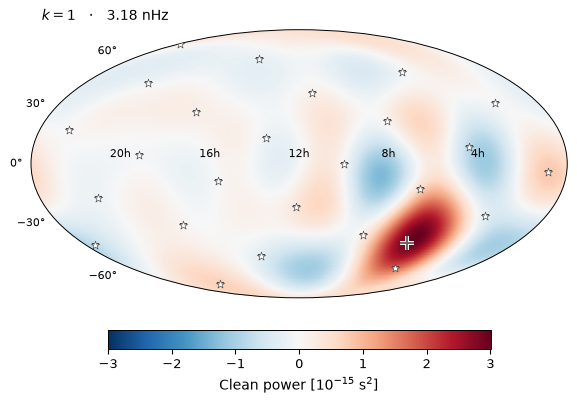

In [16]:
# Plot helper only: its input is the official pixel array, not harmonic coefficients.
def plot_clean_panel(ax, power, k, norm):
    x = (np.pi - source_ra_hours*np.pi/12 + np.pi) % (2*np.pi) - np.pi
    y = np.deg2rad(source_dec_deg)
    order = np.lexsort((x, y))
    longitude = np.unique(x)
    latitude = np.unique(y)
    z = power[order].reshape(len(latitude), len(longitude)) / 1e-15
    # Close the RA seam; values are copied, not interpolated or reconstructed.
    mesh = ax.pcolormesh(np.r_[longitude, np.pi], latitude,
                        np.column_stack((z, z[:,0])), shading="gouraud", cmap="RdBu_r", norm=norm,
                        rasterized=False)
    px = (np.pi-ra+np.pi) % (2*np.pi)-np.pi
    ax.scatter(px, dec, marker="*", s=40, facecolor="white", edgecolor="0.28", linewidth=0.45, zorder=4)
    cx = (np.pi-SOURCE_RA+np.pi) % (2*np.pi)-np.pi
    # A screen-space cross-hair stays orthogonal on the Mollweide projection.
    import matplotlib.patheffects as effects
    ax.plot([cx], [SOURCE_DEC], ls="", marker="+", ms=10, mew=1.4, color="0.4", zorder=5,
            path_effects=[effects.Stroke(linewidth=2.8, foreground="white"), effects.Normal()])
    ax.set_xticks(np.deg2rad([-120,-60,0,60,120]), labels=["20h","16h","12h","8h","4h"])
    ax.set_yticks(np.deg2rad([-60,-30,0,30,60]), labels=["−60°","−30°","0°","30°","60°"])
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=8, pad=3)
    ax.text(0.02,1.035,fr"$k={k}$   ·   {k*DF*1e9:.2f} nHz", transform=ax.transAxes, fontsize=10)
    return mesh

limit1 = float(np.max(np.abs(clean_power))/1e-15)
fig1, ax1 = plt.subplots(figsize=(7.0,4.2), subplot_kw={"projection":"mollweide"})
mesh1 = plot_clean_panel(ax1, clean_power, 1, TwoSlopeNorm(0,-limit1,limit1))
fig1.colorbar(mesh1, ax=ax1, orientation="horizontal", fraction=0.06, pad=0.10,
              label=r"Clean power [$10^{-15}$ s$^2$]")
fig1.subplots_adjust(left=0.09,right=0.97,top=0.88,bottom=0.12)
plt.show()

## 16. Repeat exactly the same steps for k = 2, 3, 4
PFOS、M、SVD、官方反演、covariance，以及官方 MATLAB clean / radiometer 转换逐项执行。
仅复用与频率无关的官方 angular response（`Gamma_lm`、`F_mat`）；每个 bin 都有自己的 pair covariance、$M$、$X$、clean 和 radiometer reconstruction。
同一 29-mode 选择必须在每个 bin 的谱上再次通过 conditioning 检查，不能静默改变 cutoff。


In [17]:
for k in BINS[1:]:
    out = PRODUCTS / f"fbin_{k:02d}"
    out.mkdir(exist_ok=True)
    xi, rhok, sigk, covk, Sk, Sk_sigma, parameter_index = os_obj.compute_PFOS(
        params=noisedict, select_freq=k-1, narrowband=True, pair_covariance=True,
        return_pair_vals=True, use_tqdm=False)
    Sk = float(Sk)
    assert xi.shape == rhok.shape == sigk.shape == (300,) and covk.shape == (300,300)
    assert all(np.all(np.isfinite(v)) for v in (xi,rhok,sigk,covk,Sk)) and Sk > 0
    assert np.all(sigk > 0) and sla.eigvalsh(covk).min() > 0
    np.testing.assert_allclose(covk, covk.T, rtol=1e-12, atol=0)
    # Same official object, sharing angular geometry only; repeat __init__ normalization explicitly.
    apta_k = copy(apta)
    apta_k.xi, apta_k.os = xi, Sk
    apta_k.rho, apta_k.sig, apta_k.os_cov = rhok/Sk, sigk/Sk, covk/Sk**2
    M_k = apta_k.fisher_matrix_sph(cross_corr=True)
    ev_k = sla.eigvalsh(M_k)
    U_k, s_k, Vh_k = sla.svd(M_k)
    assert np.linalg.norm(M_k-M_k.conj().T)/np.linalg.norm(M_k) < 1e-12
    assert np.all(ev_k > 0) and np.linalg.matrix_rank(M_k)==(LMAX+1)**2
    assert s_k[N_KEEP-1]/s_k[0] > 1/MAX_RETAINED_CONDITION
    assert s_k[N_KEEP]/s_k[0] < 1/MAX_RETAINED_CONDITION
    clms_k, err_k, cn_k, sv_k, inverse_k, X_k, _, _ = apta_k.max_lkl_clm(
        use_svd_reg=True, cross_corr=True, cutoff=N_KEEP, U_0=U_k, Vh_0=Vh_k)
    covariance_k = inverse_k @ M_k @ inverse_k
    assert np.linalg.matrix_rank(inverse_k)==N_KEEP
    np.testing.assert_allclose(clms_k, inverse_k@X_k, rtol=1e-12, atol=1e-12)
    assert np.linalg.norm(inverse_k-inverse_k.conj().T)/np.linalg.norm(inverse_k) < 1e-12
    for i,(l,m) in enumerate(lm):
        np.testing.assert_allclose(clms_k[lm.index((l,-m))], (-1.)**m*clms_k[i].conjugate(), atol=1e-10)
    np.savez_compressed(out / "pfos_pairs.npz", xi=xi,rhok=rhok,sigk=sigk,covk=covk,
                        Sk=Sk,pair_idx=pair_idx,frequency_hz=os_obj.freqs[k-1],physical_bin=k,select_freq=k-1)
    for label,value in {"M":M_k,"X":X_k,"Mprime_inv":inverse_k,"covariance":covariance_k,
                        "clms":clms_k,"eigenvalues":ev_k,"singular_values":sv_k}.items():
        assert np.all(np.isfinite(value))
        np.save(out / f"{label}.npy",value)
    pixel_k = official_power_maps(out, clms_k, X_k, M_k)
    np.testing.assert_array_equal((pixel_k["RA_hours"]+12)%24,source_ra_hours)
    np.testing.assert_array_equal(-pixel_k["DEC_deg"],source_dec_deg)
    assert int(pixel_k["target_pixel"])-1 == TRUE_CW_PIXEL
    clean_k = Sk*pixel_k["clean_normalized"]
    radiometer_at_true_k = Sk*float(pixel_k["target_radiometer_normalized"])
    assert clean_k.shape == (65160,) and np.all(np.isfinite(clean_k))
    assert np.isfinite(radiometer_at_true_k)
    np.savez_compressed(out / "pixel_power_maps.npz",ra_hours=source_ra_hours,dec_deg=source_dec_deg,
        clean_normalized=pixel_k["clean_normalized"],clean_power_s2=clean_k,
        radiometer_power_at_true_cw_s2=radiometer_at_true_k,
        radiometer_normalized_at_true_cw=pixel_k["target_radiometer_normalized"],
        radiometer_sigma_normalized_at_true_cw=pixel_k["target_radiometer_sigma_normalized"],
        Sk=Sk,true_cw_pixel=TRUE_CW_PIXEL)
    all_clean_maps[k] = clean_k
    all_radiometer_at_true[k] = radiometer_at_true_k
    all_Sk[k] = Sk
    all_conditions[k] = float(sv_k[0]/sv_k[N_KEEP-1])
    print(f"k={k}: Sk={Sk:.6e} s²; M={M_k.shape}; rank={np.linalg.matrix_rank(M_k)}; "
          f"kept={N_KEEP}; retained condition={all_conditions[k]:.3f}; "
          f"clean/radiometer at true CW=[{clean_k[TRUE_CW_PIXEL]:.6e}, "
          f"{radiometer_at_true_k:.6e}] s²")
    print("  clms[:4] =",clms_k[:4])


k=2: Sk=4.078255e-16 s²; M=(49, 49); rank=49; kept=29; retained condition=13.232; clean/radiometer at true CW=[1.715565e-14, 6.546712e-15] s²
  clms[:4] = [ 3.47211278-1.62630326e-17j -0.08685726-2.75965021e+00j
  4.70673315+3.67761377e-16j  0.08685726-2.75965021e+00j]


k=3: Sk=3.675363e-16 s²; M=(49, 49); rank=49; kept=29; retained condition=13.232; clean/radiometer at true CW=[1.294561e-14, 5.161044e-15] s²
  clms[:4] = [ 3.48502540e+00-1.43114687e-17j  3.31628861e-03-2.65901321e+00j
  4.31660856e+00+4.73232564e-15j -3.31628861e-03-2.65901321e+00j]


k=4: Sk=3.971484e-17 s²; M=(49, 49); rank=49; kept=29; retained condition=13.232; clean/radiometer at true CW=[1.188374e-15, 4.958174e-16] s²
  clms[:4] = [ 3.49517859+5.16080234e-17j  0.04784282-2.61728959e+00j
  3.97610902-3.85455556e-15j -0.04784282-2.61728959e+00j]


## 17. Four-panel clean power and normalized response at the true CW position
统一 Mollweide 投影、RA 方向、字体、坐标和色标；白星是 pulsars，灰色 cross-hair 是注入位置。颜色使用同一个对称零中心范围，保留全部负值。不同 bin 的峰值幅度没有被单独归一化。

最后的 response figure 中，Clean points 是 $k=1,2,3,4$ 四个实际 analyzed Fourier bins 在 true-CW pixel 的 signed clean power。Finite-sampling window 使用 J00 的实际 barycentric TOAs；$\mathrm{sinc}^2$ 是理想连续有限窗参考。三者分别按各自在四个 analyzed bins 中的最大值归一化，因此连续理论曲线在 $fT=2.5$ 可以高于 1。这两条理论曲线只是 frequency-window baselines，不包含 PFOS、angular response、Fisher regularisation 或 clean-map estimator 的全部效应。


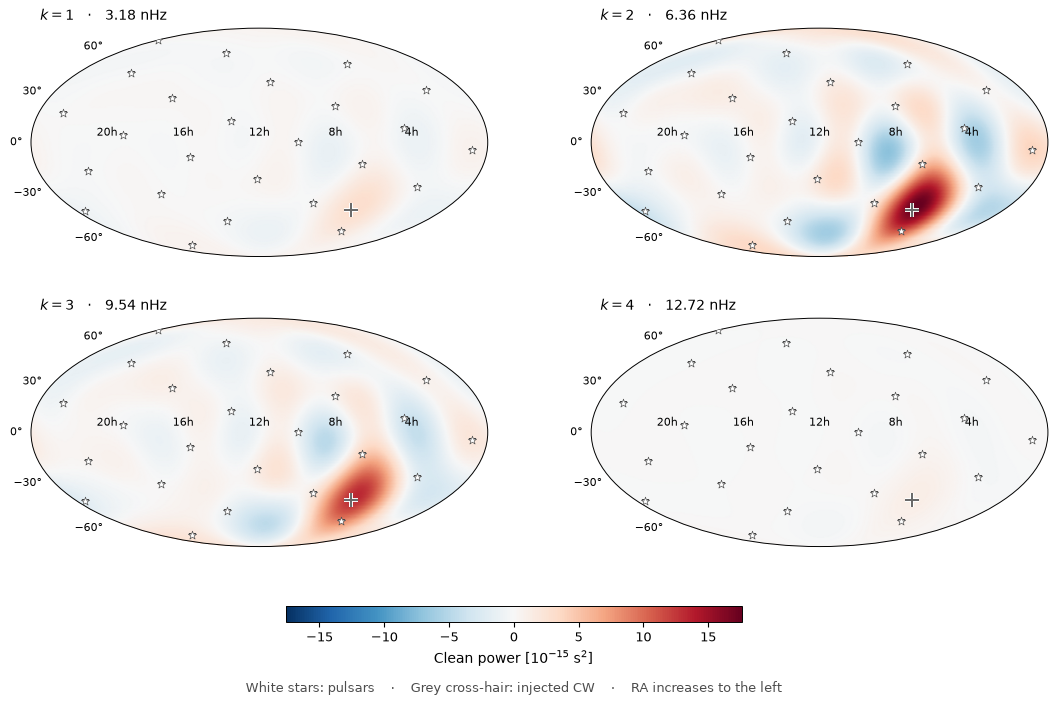

,bin,frequency_nhz,clean_power_at_true_cw_s2,radiometer_power_at_true_cw_s2
0,1,3.179681,2.916433e-15,1.075836e-15
1,2,6.359362,1.715565e-14,6.546712e-15
2,3,9.539044,1.294561e-14,5.161044e-15
3,4,12.718725,1.188374e-15,4.958174e-16


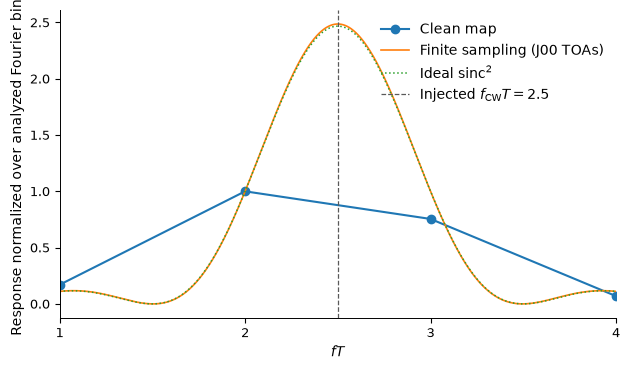

Normalized maxima at analyzed bins (clean, finite sampling, sinc²): 1.0 1.0 1.0
Continuous theory maxima (finite sampling, sinc²): 2.486463497739756 2.467401100272339
Saved: /home/liujiyu/projects/Leakage/data/products/meerkat_maps/cw_ra6h_dec-45_f2p5T/clean_power_fbin_01-04.png
Saved: /home/liujiyu/projects/Leakage/data/products/meerkat_maps/cw_ra6h_dec-45_f2p5T/power_at_true_cw.csv


In [18]:
limit = max(float(np.max(np.abs(v))) for v in all_clean_maps.values()) / 1e-15
norm = TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit)
fig4, axes = plt.subplots(2,2,figsize=(11.4,7.2),subplot_kw={"projection":"mollweide"})
for k, ax_map in zip(BINS, axes.flat):
    mesh = plot_clean_panel(ax_map, all_clean_maps[k], k, norm)
fig4.subplots_adjust(left=0.065,right=0.98,top=0.94,bottom=0.22,wspace=0.16,hspace=0.27)
cax = fig4.add_axes([0.30,0.115,0.40,0.022])
fig4.colorbar(mesh,cax=cax,orientation="horizontal",label=r"Clean power [$10^{-15}$ s$^2$]")
fig4.text(0.5,0.018,"White stars: pulsars    ·    Grey cross-hair: injected CW    ·    RA increases to the left",
          ha="center",fontsize=9,color="0.3")
fig4.savefig(PRODUCTS / "clean_power_fbin_01-04.png",dpi=400)
fig4.savefig(PRODUCTS / "clean_power_fbin_01-04.pdf")
plt.show()

summary=[]
for k in BINS:
    clean_peak=int(np.argmax(all_clean_maps[k]))
    summary.append({"bin":k,"frequency_nhz":float(k*DF*1e9),"fT":float(k),"Sk_s2":all_Sk[k],
        "clean_power_at_true_cw_s2":float(all_clean_maps[k][TRUE_CW_PIXEL]),
        "radiometer_power_at_true_cw_s2":float(all_radiometer_at_true[k]),
        "clean_min_power_s2":float(all_clean_maps[k].min()),
        "clean_max_power_s2":float(all_clean_maps[k].max()),
        "clean_peak_ra_hours":float(source_ra_hours[clean_peak]),
        "clean_peak_dec_deg":float(source_dec_deg[clean_peak]),
        "retained_condition":all_conditions[k]})
true_position_power = pd.DataFrame(summary)
display(true_position_power[["bin","frequency_nhz","clean_power_at_true_cw_s2",
                             "radiometer_power_at_true_cw_s2"]])
true_position_power.to_csv(PRODUCTS / "power_at_true_cw.csv",index=False)
write_json(PRODUCTS / "power_at_true_cw.json", {
    "true_cw_ra_hours":true_ra_hours,"true_cw_dec_deg":true_dec_deg,
    "pixel_index":TRUE_CW_PIXEL,"pixel_match":"exact 1-degree grid coordinate; no interpolation",
    "injection_fT":CW_CYCLES,"bins":summary})

bin_fT = np.asarray(BINS, dtype=float)
clean_at_bins = np.asarray([all_clean_maps[k][TRUE_CW_PIXEL] for k in BINS], dtype=float)
clean_norm_denominator = float(np.max(clean_at_bins))
assert clean_norm_denominator > 0
clean_normalized = clean_at_bins / clean_norm_denominator
np.testing.assert_allclose(np.max(clean_normalized), 1.0, rtol=0, atol=1e-14)
np.testing.assert_array_equal(np.signbit(clean_normalized), np.signbit(clean_at_bins))

# Window-only finite-sampling baseline from the canonical J00 barycentric TOAs.
j00_toas_s = np.asarray(enterprise_psrs[0].toas, dtype=float)
j00_relative_toas_s = j00_toas_s - j00_toas_s[0]
theory_fT = np.linspace(float(bin_fT[0]), float(bin_fT[-1]), 1601)
theory_frequencies_hz = theory_fT / T_OBS
bin_frequencies_hz = bin_fT / T_OBS
window_at_bins = np.abs(np.exp(
    -2j*np.pi*np.outer(bin_frequencies_hz - F_CW, j00_relative_toas_s)
).sum(axis=1))**2
window_norm_denominator = float(np.max(window_at_bins))
assert window_norm_denominator > 0
window_normalized_at_bins = window_at_bins / window_norm_denominator
window_normalized = np.abs(np.exp(
    -2j*np.pi*np.outer(theory_frequencies_hz - F_CW, j00_relative_toas_s)
).sum(axis=1))**2 / window_norm_denominator
np.testing.assert_allclose(np.max(window_normalized_at_bins), 1.0, rtol=0, atol=1e-14)

sinc_at_bins = np.sinc(bin_fT - CW_CYCLES)**2
sinc_norm_denominator = float(np.max(sinc_at_bins))
assert sinc_norm_denominator > 0
sinc_normalized_at_bins = sinc_at_bins / sinc_norm_denominator
sinc_normalized = np.sinc(theory_fT - CW_CYCLES)**2 / sinc_norm_denominator
np.testing.assert_allclose(np.max(sinc_normalized_at_bins), 1.0, rtol=0, atol=1e-14)
assert np.max(window_normalized) > 1 and np.max(sinc_normalized) > 1

fig_response, ax_response = plt.subplots(figsize=(6.4,3.8))
ax_response.plot(bin_fT, clean_normalized, "o-", label="Clean map")
ax_response.plot(theory_fT, window_normalized, lw=1.2, label="Finite sampling (J00 TOAs)")
ax_response.plot(theory_fT, sinc_normalized, lw=1.1, ls=":", label=r"Ideal $\mathrm{sinc}^2$")
ax_response.axvline(CW_CYCLES, color="0.35", lw=0.9, ls="--",
                    label=fr"Injected $f_{{\mathrm{{CW}}}}T={CW_CYCLES:g}$")
ax_response.set(xlabel=r"$fT$", ylabel="Response normalized over analyzed Fourier bins",
                xlim=(bin_fT[0], bin_fT[-1]), xticks=BINS)
ax_response.legend(frameon=False)
ax_response.spines[["right","top"]].set_visible(False)
fig_response.tight_layout()
fig_response.savefig(PRODUCTS / "power_at_true_cw.png", dpi=400)
fig_response.savefig(PRODUCTS / "power_at_true_cw.pdf")
plt.show()
print("Normalized maxima at analyzed bins (clean, finite sampling, sinc²):",
      np.max(clean_normalized), np.max(window_normalized_at_bins), np.max(sinc_normalized_at_bins))
print("Continuous theory maxima (finite sampling, sinc²):",
      np.max(window_normalized), np.max(sinc_normalized))

run_metadata = {**provenance,"defiant_commit":"25d38082bbf2b9b33829f59438ac66a5dfc112fa",
    "injection_metadata_sha256":sha256(INJECTION/"injection.json"),
    "baseline_metadata_sha256":sha256(BASELINE/"metadata.json"),"lmax":LMAX,"n_keep":N_KEEP,
    "nside":NSIDE,"n_fourier":N_FOURIER,"narrowband":True,"pair_covariance":True,
    "T_obs_seconds":T_OBS,"fCW_hz":F_CW,"fCW_T":CW_CYCLES,"pixel_resolution_deg":1,
    "true_cw_ra_hours":true_ra_hours,"true_cw_dec_deg":true_dec_deg,"true_cw_pixel":TRUE_CW_PIXEL,
    "pixel_conversion":"upstream makemap plus the elementwise-equivalent diagPixel formula executed by Octave 9.4.0; explicit antipodal relabel",
    "clean_power_definition":"Sk * official makemap(clms), where clms reconstruct rhok/Sk; PSD/T units s^2",
    "radiometer_power_definition":"Sk * Re[(U X)/diag(U M U^dagger)] at the exact true-CW row using the official diagPixel definition; PSD/T units s^2",
    "monopole_removed":False,"negative_values_clipped":False,"bins":summary}
write_json(PRODUCTS/"run_metadata.json",run_metadata)
for k,row in zip(BINS,summary):
    write_json(PRODUCTS/f"fbin_{k:02d}"/"metadata.json",{**run_metadata,"bins":[row]})
print("Saved:",PRODUCTS/"clean_power_fbin_01-04.png")
print("Saved:",PRODUCTS/"power_at_true_cw.csv")
